In [1]:
! pip install feature_engine==1.8.0 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.1/357.1 kB 8.0 MB/s eta 0:00:00


In [2]:
!pip install optuna==4.8.0 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.8 MB/s eta 0:00:00


In [3]:
!pip uninstall scikit-learn -y
!pip install scikit-learn==1.5.2 -q

Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 65.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [4]:
# !pip uninstall lightgbm -y
!pip install lightgbm

In [5]:
import torch
print(torch.cuda.is_available()) # Deve retornar True no Colab com GPU ativa

True


In [6]:
import pandas as pd
import numpy as np
import sys
import os
import gc

import unicodedata
import re

import seaborn as sns
import matplotlib.pyplot as plt

import feature_engine
from feature_engine.selection import (
    RecursiveFeatureElimination,
    DropConstantFeatures,
    DropDuplicateFeatures,
)
import optuna

from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.preprocessing import StandardScaler
import sklearn

import xgboost
import lightgbm
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import time

import tensorflow as tf
print(tf.__version__)

print(f"Versão:")
print(f'Python: {sys.version}')
print(f'Pandas: {pd.__version__}')
print(f'Numpy: {np.__version__}')
print("Feature Engine:", feature_engine.__version__)
print("Scikit Learn:", sklearn.__version__)
print("Optuna:", optuna.__version__)
print("XGBoost:", xgboost.__version__)
print("LightGBM:", lightgbm.__version__)
print("Tensorflow", tf.__version__)

2.20.0
Versão:
Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Pandas: 2.2.2
Numpy: 2.0.2
Feature Engine: 1.8.0
Scikit Learn: 1.5.2
Optuna: 4.8.0
XGBoost: 3.2.0
LightGBM: 4.6.0
Tensorflow 2.20.0


In [7]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
path_main = '/content/drive/MyDrive/ML-UFF'

Mounted at /content/drive


In [8]:
def get_data_frame(path_dataset: str):
  data = pd.read_csv(path_dataset)
  return data

In [9]:
path = f'{path_main}/df_feat.csv'
df = get_data_frame(path)

In [10]:
df['data'] = pd.to_datetime(df['data'])
df.set_index('data', inplace=True)

In [11]:
df.shape, df.columns

((2245, 66),
 Index(['total_casos', 'score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia',
        'temp_min_dia', 'umidade_dia', 'year', 'month', 'day_week',
        'chuva_acum_7d', 'gravidade_lag_7d', 'chuva_acum_15d',
        'gravidade_lag_15d', 'chuva_acum_21d', 'gravidade_lag_21d',
        'chuva_acum_30d', 'gravidade_lag_30d', 'chuva_acum_45d',
        'gravidade_lag_45d', 'chuva_acum_50d', 'gravidade_lag_50d',
        'chuva_acum_60d', 'gravidade_lag_60d', 'casos_mm7d', 'casos_mm15d',
        'casos_mm21d', 'casos_mm30d', 'casos_mm45d', 'casos_mm50d',
        'casos_mm60d', 'temp_min_lag_7d', 'temp_min_lag_15d',
        'temp_min_lag_21d', 'temp_min_lag_30d', 'temp_min_lag_45d',
        'temp_min_lag_50d', 'temp_min_lag_60d', 'temp_max_lag_7d',
        'temp_max_lag_15d', 'temp_max_lag_21d', 'temp_max_lag_30d',
        'temp_max_lag_45d', 'temp_max_lag_50d', 'temp_max_lag_60d',
        'faixa_chuva', 'faixa_umidade', 'day_month', 'day_month_start',
        'day_month_end', '

In [12]:
def print_nan(df):
    nan_count = df.isna().sum()
    # Filtra apenas onde a contagem é maior que zero
    nan_only = nan_count[nan_count > 0].sort_values(ascending=False)

    if nan_only.empty:
        print("Nenhum valor NaN encontrado!")
    else:
        print("Colunas com valores NaN:")
        print(nan_only)

In [13]:
print_nan(df)

Nenhum valor NaN encontrado!


### Train Test Split

In [14]:
# Separar o df
def train_test_split_by_date(
    data: pd.DataFrame | pd.Series,
    start_date: str,
    split_date: str,
    end_date: str | None = None,
):
    if not isinstance(data.index, pd.DatetimeIndex):
        raise ValueError("data must have a DatetimeIndex")

    # garantir ordem temporal
    data = data.sort_index()

    start_date = pd.to_datetime(start_date)
    split_date = pd.to_datetime(split_date)
    end_date = pd.to_datetime(end_date) if end_date else data.index.max()

    if not (start_date < split_date < end_date):
        raise ValueError("start_date < split_date < end_date is required")

    # 🔑 slicing robusto (não depende da data existir no índice)
    start_pos = data.index.searchsorted(start_date, side="left")
    end_pos = data.index.searchsorted(end_date, side="right")

    data = data.iloc[start_pos:end_pos]

    split_pos = data.index.searchsorted(split_date, side="right")
    train = data.iloc[:split_pos]
    test = data.iloc[split_pos:]

    return train, test

In [15]:
start_date = df.index.min().strftime('%Y-%m-%d')
split_date_test = '2025-12-24' # 60 dias maior lag gerado
split_date_validation = '2025-08-26' # 60 dias
end_date = df.index.max().strftime('%Y-%m-%d')

start_date, split_date_validation, split_date_test, end_date

('2020-03-01', '2025-08-26', '2025-12-24', '2026-04-23')

In [16]:
df_train_temp, df_test = train_test_split_by_date(df, start_date, split_date_test, end_date)

In [17]:
df_train, df_val = train_test_split_by_date(df_train_temp, start_date, split_date_validation, split_date_test)

In [18]:
df_train.shape, df_train.index.unique()

((2005, 66),
 DatetimeIndex(['2020-03-01', '2020-03-02', '2020-03-03', '2020-03-04',
                '2020-03-05', '2020-03-06', '2020-03-07', '2020-03-08',
                '2020-03-09', '2020-03-10',
                ...
                '2025-08-17', '2025-08-18', '2025-08-19', '2025-08-20',
                '2025-08-21', '2025-08-22', '2025-08-23', '2025-08-24',
                '2025-08-25', '2025-08-26'],
               dtype='datetime64[ns]', name='data', length=2005, freq=None))

In [19]:
df_val.shape, df_val.index.unique()

((120, 66),
 DatetimeIndex(['2025-08-27', '2025-08-28', '2025-08-29', '2025-08-30',
                '2025-08-31', '2025-09-01', '2025-09-02', '2025-09-03',
                '2025-09-04', '2025-09-05',
                ...
                '2025-12-15', '2025-12-16', '2025-12-17', '2025-12-18',
                '2025-12-19', '2025-12-20', '2025-12-21', '2025-12-22',
                '2025-12-23', '2025-12-24'],
               dtype='datetime64[ns]', name='data', length=120, freq=None))

In [20]:
df_test.shape, df_test.index.unique()

((120, 66),
 DatetimeIndex(['2025-12-25', '2025-12-26', '2025-12-27', '2025-12-28',
                '2025-12-29', '2025-12-30', '2025-12-31', '2026-01-01',
                '2026-01-02', '2026-01-03',
                ...
                '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17',
                '2026-04-18', '2026-04-19', '2026-04-20', '2026-04-21',
                '2026-04-22', '2026-04-23'],
               dtype='datetime64[ns]', name='data', length=120, freq=None))

In [21]:
df_train.describe()

,total_casos,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
count,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,...,2005.000000,2.005000e+03,2005.000000,2.005000e+03,2005.000000,2005.000000,2005.000000,2005.000000,2005.000000,2.005000e+03
mean,44.942643,11.634130,30.729394,11.804140,30.199594,18.566284,78.124558,2022.415960,6.426434,2.999002,...,-0.000062,2.698475e-04,0.000360,-1.735400e-04,-0.001930,0.001402,0.001745,0.057908,-0.001244,7.505943e-05
std,129.641138,0.274246,8.451706,33.359878,4.177824,3.094147,7.382627,1.612868,3.344522,2.001745,...,0.707411,7.071557e-01,0.707530,7.070360e-01,0.707053,0.707509,0.706841,0.705349,0.706845,7.077203e-01
min,0.000000,9.000000,0.000000,0.000000,18.700000,8.300000,39.593750,2020.000000,1.000000,0.000000,...,-0.900969,-9.749279e-01,-0.900969,-9.749279e-01,-1.000000,-0.994522,-0.999963,-0.999991,-0.999963,-9.999907e-01
25%,3.000000,11.517241,26.666667,0.000000,27.100000,16.400000,73.958333,2021.000000,4.000000,1.000000,...,-0.900969,-7.818315e-01,-0.900969,-7.818315e-01,-0.669131,-0.743145,-0.708627,-0.648630,-0.708627,-7.055836e-01
50%,11.000000,11.625000,30.363636,0.200000,30.200000,19.000000,78.468750,2022.000000,6.000000,3.000000,...,-0.222521,-4.311252e-14,-0.222521,-6.073010e-14,-0.104528,0.000000,0.004304,0.128748,0.004304,2.572996e-15
75%,35.000000,11.765957,33.924781,6.200000,33.300000,21.000000,83.171875,2024.000000,9.000000,5.000000,...,0.623490,7.818315e-01,0.623490,7.818315e-01,0.669131,0.743145,0.702527,0.752667,0.702527,7.055836e-01
max,1501.000000,12.000000,68.000000,520.600000,42.500000,25.400000,95.359375,2025.000000,12.000000,6.000000,...,1.000000,9.749279e-01,1.000000,9.749279e-01,1.000000,0.994522,1.000000,0.999991,1.000000,9.999907e-01


In [22]:
df_val.describe()

,total_casos,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.0,120.000000,120.000000,...,120.000000,1.200000e+02,120.000000,1.200000e+02,1.200000e+02,1.200000e+02,120.000000,120.000000,120.000000,120.000000
mean,7.366667,11.573481,28.250134,8.280000,30.158333,18.225000,77.165972,2025.0,10.316667,2.991667,...,0.005196,-6.515262e-03,-0.001854,8.124399e-03,-1.580911e-16,-2.914335e-17,-0.462306,-0.691084,-0.162612,0.393777
std,2.857787,0.179567,6.356627,18.324496,4.261762,2.414426,8.187556,0.0,1.173828,2.002082,...,0.709394,7.106995e-01,0.707398,7.126856e-01,7.100716e-01,7.100716e-01,0.454632,0.323388,0.741514,0.524911
min,2.000000,11.142857,14.305556,0.000000,21.500000,12.100000,51.916667,2025.0,8.000000,0.000000,...,-0.900969,-9.749279e-01,-0.900969,-9.749279e-01,-1.000000e+00,-9.945219e-01,-0.999963,-0.999991,-0.999963,-0.763889
25%,5.000000,11.500000,24.809524,0.000000,27.175000,16.825000,72.373698,2025.0,9.000000,1.000000,...,-0.900969,-7.818315e-01,-0.900969,-7.818315e-01,-6.691306e-01,-7.431448e-01,-0.891957,-0.966289,-0.867432,0.023667
50%,7.000000,11.563492,27.734848,0.200000,29.850000,18.400000,78.645833,2025.0,10.000000,3.000000,...,-0.222521,-1.724402e-13,-0.222521,-2.429798e-13,5.342948e-15,-1.225080e-14,-0.555997,-0.831140,-0.381633,0.512367
75%,9.000000,11.675000,31.664773,8.200000,32.900000,19.825000,82.998698,2025.0,11.000000,5.000000,...,0.623490,7.818315e-01,0.623490,7.818315e-01,6.691306e-01,7.431448e-01,-0.077384,-0.452060,0.591195,0.868519
max,16.000000,12.000000,52.166667,134.400000,40.000000,22.800000,95.046875,2025.0,12.000000,6.000000,...,1.000000,9.749279e-01,1.000000,9.749279e-01,1.000000e+00,9.945219e-01,0.421101,0.043022,0.999852,0.999991


In [23]:
df_test.describe()

,total_casos,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.0,...,120.000000,1.200000e+02,120.000000,1.200000e+02,1.200000e+02,1.200000e+02,120.000000,120.000000,120.000000,120.000000
mean,10.550000,11.592108,32.377215,23.183333,32.079583,21.496667,82.836634,2025.941667,2.966667,3.0,...,0.005196,6.515262e-03,-0.001854,-8.124399e-03,2.368476e-16,-4.584296e-16,0.827735,-0.078603,0.418417,-0.080191
std,5.327667,0.223171,7.406475,38.192116,3.607849,1.136184,8.548816,0.235355,2.496833,2.0,...,0.709394,7.106995e-01,0.707398,7.126856e-01,7.100716e-01,7.100716e-01,0.155771,0.535728,0.482546,0.769756
min,0.000000,11.000000,10.000000,0.000000,22.900000,17.500000,56.947917,2025.000000,1.000000,0.0,...,-0.900969,-9.749279e-01,-0.900969,-9.749279e-01,-1.000000e+00,-9.945219e-01,0.436651,-0.899631,-0.618671,-0.999917
25%,6.000000,11.491667,27.866667,0.000000,29.600000,21.100000,77.618490,2026.000000,1.000000,1.0,...,-0.900969,-7.818315e-01,-0.900969,-7.818315e-01,-6.691306e-01,-7.431448e-01,0.714673,-0.570226,0.021516,-0.866330
50%,10.000000,11.600000,31.538462,10.000000,31.750000,21.300000,84.578125,2026.000000,3.000000,3.0,...,-0.222521,-1.253939e-13,-0.222521,-2.057332e-13,1.219858e-14,-5.390303e-15,0.869589,-0.094533,0.512371,-0.188199
75%,14.000000,11.750000,36.000000,27.800000,35.025000,22.300000,91.055990,2026.000000,3.250000,5.0,...,0.623490,7.818315e-01,0.623490,7.818315e-01,6.691306e-01,7.431448e-01,0.966848,0.405414,0.869589,0.741139
max,25.000000,12.000000,62.666667,210.400000,40.800000,24.200000,96.015625,2026.000000,12.000000,6.0,...,1.000000,9.749279e-01,1.000000,9.749279e-01,1.000000e+00,9.945219e-01,1.000000,0.801361,1.000000,0.999917


In [24]:
print(f"Validação: {df_val.index.min()} até {df_val.index.max()} (Tamanho: {len(df_val)})")
print(f"Teste: {df_test.index.min()} até {df_test.index.max()} (Tamanho: {len(df_test)})")
print("Val e Test são iguais?", df_val.equals(df_test))

Validação: 2025-08-27 00:00:00 até 2025-12-24 00:00:00 (Tamanho: 120)
Teste: 2025-12-25 00:00:00 até 2026-04-23 00:00:00 (Tamanho: 120)
Val e Test são iguais? False


### Split

In [25]:
def split_target(df: pd.DataFrame, columns_target: str):
    y = df[columns_target]
    X = df.drop(columns=[columns_target])

    return X, y

In [26]:
column_target = 'total_casos'

In [27]:
X_train, y_train = split_target(df_train, column_target)
X_val, y_val = split_target(df_val, column_target)
X_test, y_test = split_target(df_test, column_target)

In [28]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
X_test.shape, y_test.shape

(2005, 65) (2005,)
(120, 65) (120,)


((120, 65), (120,))

In [29]:
y_train.isna().sum().sum(), y_val.isna().sum().sum(), y_test.isna().sum().sum()

(np.int64(0), np.int64(0), np.int64(0))

In [30]:
X_train.index, X_val.index, X_test.index

(DatetimeIndex(['2020-03-01', '2020-03-02', '2020-03-03', '2020-03-04',
                '2020-03-05', '2020-03-06', '2020-03-07', '2020-03-08',
                '2020-03-09', '2020-03-10',
                ...
                '2025-08-17', '2025-08-18', '2025-08-19', '2025-08-20',
                '2025-08-21', '2025-08-22', '2025-08-23', '2025-08-24',
                '2025-08-25', '2025-08-26'],
               dtype='datetime64[ns]', name='data', length=2005, freq=None),
 DatetimeIndex(['2025-08-27', '2025-08-28', '2025-08-29', '2025-08-30',
                '2025-08-31', '2025-09-01', '2025-09-02', '2025-09-03',
                '2025-09-04', '2025-09-05',
                ...
                '2025-12-15', '2025-12-16', '2025-12-17', '2025-12-18',
                '2025-12-19', '2025-12-20', '2025-12-21', '2025-12-22',
                '2025-12-23', '2025-12-24'],
               dtype='datetime64[ns]', name='data', length=120, freq=None),
 DatetimeIndex(['2025-12-25', '2025-12-26', '2025-12-

# Scaler

In [31]:
X_train.columns

Index(['score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia', 'temp_min_dia',
       'umidade_dia', 'year', 'month', 'day_week', 'chuva_acum_7d',
       'gravidade_lag_7d', 'chuva_acum_15d', 'gravidade_lag_15d',
       'chuva_acum_21d', 'gravidade_lag_21d', 'chuva_acum_30d',
       'gravidade_lag_30d', 'chuva_acum_45d', 'gravidade_lag_45d',
       'chuva_acum_50d', 'gravidade_lag_50d', 'chuva_acum_60d',
       'gravidade_lag_60d', 'casos_mm7d', 'casos_mm15d', 'casos_mm21d',
       'casos_mm30d', 'casos_mm45d', 'casos_mm50d', 'casos_mm60d',
       'temp_min_lag_7d', 'temp_min_lag_15d', 'temp_min_lag_21d',
       'temp_min_lag_30d', 'temp_min_lag_45d', 'temp_min_lag_50d',
       'temp_min_lag_60d', 'temp_max_lag_7d', 'temp_max_lag_15d',
       'temp_max_lag_21d', 'temp_max_lag_30d', 'temp_max_lag_45d',
       'temp_max_lag_50d', 'temp_max_lag_60d', 'faixa_chuva', 'faixa_umidade',
       'day_month', 'day_month_start', 'day_month_end', 'day_quarter_start',
       'day_quarter_end', 'day

In [32]:
fourier = X_train.filter(like='ciclo')
cols_fourier = fourier.columns.to_list()
cols_fourier

['ciclos_fourier_cos_p7_k1',
 'ciclos_fourier_sin_p7_k1',
 'ciclos_fourier_cos_p7_k2',
 'ciclos_fourier_sin_p7_k2',
 'ciclos_fourier_cos_p7_k3',
 'ciclos_fourier_sin_p7_k3',
 'ciclos_fourier_cos_p30_k1',
 'ciclos_fourier_sin_p30_k1',
 'ciclos_fourier_cos_p365_k1',
 'ciclos_fourier_sin_p365_k1',
 'ciclos_fourier_cos_p365_k2',
 'ciclos_fourier_sin_p365_k2']

In [33]:
X_train_fourier = X_train[cols_fourier]
X_val_fourier = X_val[cols_fourier]
X_test_fourier = X_test[cols_fourier]
X_test_fourier

,ciclos_fourier_cos_p7_k1,ciclos_fourier_sin_p7_k1,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
data,,,,,,,,,,,,
2025-12-25,-0.900969,-4.338837e-01,0.623490,7.818315e-01,-0.222521,-9.749279e-01,0.500000,-0.866025,0.436651,-0.899631,-0.618671,-0.785650
2025-12-26,-0.222521,-9.749279e-01,-0.900969,4.338837e-01,0.623490,7.818315e-01,0.669131,-0.743145,0.452072,-0.891981,-0.591261,-0.806480
2025-12-27,0.623490,-7.818315e-01,-0.222521,-9.749279e-01,-0.900969,-4.338837e-01,0.809017,-0.587785,0.467359,-0.884068,-0.563151,-0.826354
2025-12-28,1.000000,3.922831e-14,1.000000,7.845662e-14,1.000000,-5.644361e-13,0.913545,-0.406737,0.482508,-0.875892,-0.534373,-0.845249
2025-12-29,0.623490,7.818315e-01,-0.222521,9.749279e-01,-0.900969,4.338837e-01,0.978148,-0.207912,0.497513,-0.867456,-0.504961,-0.863142
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-19,1.000000,-7.837740e-14,1.000000,-1.567548e-13,1.000000,2.196152e-13,-0.500000,-0.866025,0.651899,0.758306,-0.150055,0.988678
2026-04-20,0.623490,7.818315e-01,-0.222521,9.749279e-01,-0.900969,4.338837e-01,-0.309017,-0.951057,0.638749,0.769415,-0.183998,0.982927
2026-04-21,-0.222521,9.749279e-01,-0.900969,-4.338837e-01,0.623490,-7.818315e-01,-0.104528,-0.994522,0.625411,0.780296,-0.217723,0.976011


In [34]:
X_train_s = X_train.drop(columns=cols_fourier)
X_val_s = X_val.drop(columns=cols_fourier)
X_test_s = X_test.drop(columns=cols_fourier)

In [35]:
X_train_s.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2005 entries, 2020-03-01 to 2025-08-26
Data columns (total 53 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   score_gravidade    2005 non-null   float64
 1   idade              2005 non-null   float64
 2   chuva_dia          2005 non-null   float64
 3   temp_max_dia       2005 non-null   float64
 4   temp_min_dia       2005 non-null   float64
 5   umidade_dia        2005 non-null   float64
 6   year               2005 non-null   int64  
 7   month              2005 non-null   int64  
 8   day_week           2005 non-null   int64  
 9   chuva_acum_7d      2005 non-null   float64
 10  gravidade_lag_7d   2005 non-null   float64
 11  chuva_acum_15d     2005 non-null   float64
 12  gravidade_lag_15d  2005 non-null   float64
 13  chuva_acum_21d     2005 non-null   float64
 14  gravidade_lag_21d  2005 non-null   float64
 15  chuva_acum_30d     2005 non-null   float64
 16  gravid

In [36]:
def encode_categorical_columns(df):
    df_encoded = df.copy()
    cat_cols = df_encoded.select_dtypes(include=['category', 'object']).columns

    for col in cat_cols:
        print(f"Transformando a coluna: {col}")
        df_encoded[col] = df_encoded[col].astype('category').cat.codes

    return df_encoded

In [37]:
X_train_s = encode_categorical_columns(X_train_s)
X_val_s = encode_categorical_columns(X_val_s)
X_test_s = encode_categorical_columns(X_test_s)

Transformando a coluna: faixa_chuva
Transformando a coluna: faixa_umidade
Transformando a coluna: faixa_chuva
Transformando a coluna: faixa_umidade
Transformando a coluna: faixa_chuva
Transformando a coluna: faixa_umidade


In [38]:
scaler = StandardScaler()

In [39]:
X_train_scaled = scaler.fit_transform(X_train_s)
X_val_scaled = scaler.transform(X_val_s)
X_test_scaled = scaler.transform(X_test_s)

In [40]:
X_train_scaled_df = pd.DataFrame(X_train_scaled,
                                 columns=X_train_s.columns,
                                 index=X_train_s.index)

X_val_scaled_df = pd.DataFrame(X_val_scaled,
                                 columns=X_val_s.columns,
                                 index=X_val_s.index)

X_test_scaled_df = pd.DataFrame(X_test_scaled,
                                 columns=X_test_s.columns,
                                 index=X_test_s.index)

X_train_scaled_df

,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,chuva_acum_7d,...,temp_max_lag_60d,faixa_chuva,faixa_umidade,day_month,day_month_start,day_month_end,day_quarter_start,day_quarter_end,day_year_start,day_year_end
data,,,,,,,,,,,,,,,,,,,,,
2020-03-01,0.813390,-0.441369,15.255535,-1.436415,0.883732,1.937805,-1.498302,-1.024747,1.499564,4.710811,...,1.742544,0.499203,-1.369086,-1.672869,5.420220,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2020-03-02,0.118672,0.071475,1.403109,-1.460357,0.334171,1.731752,-1.498302,-1.024747,-1.498567,5.221635,...,0.488740,0.499203,-1.369086,-1.559105,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2020-03-03,0.773310,0.059337,0.029859,-0.550566,0.431152,0.932944,-1.498302,-1.024747,-0.998879,5.287261,...,-0.282832,0.499203,-1.369086,-1.445341,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2020-03-04,-0.124480,-1.104123,-0.263980,-0.694217,0.786751,0.615396,-1.498302,-1.024747,-0.499190,5.281940,...,-0.186385,0.499203,1.338922,-1.331577,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2020-03-05,0.339718,0.128857,-0.233996,-0.311147,-0.312372,0.175064,-1.498302,-1.024747,0.000498,4.840291,...,-0.138162,0.499203,1.338922,-1.217813,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-22,0.929176,-0.721900,-0.353931,0.598644,-0.829607,-0.166476,1.602540,0.470608,0.500187,-0.713138,...,0.874526,-0.392072,-0.466417,0.716174,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2025-08-23,-1.097085,0.515284,-0.353931,1.125366,-1.088224,-2.856456,1.602540,0.470608,0.999876,-0.734422,...,-1.006180,-0.392072,0.436253,0.829938,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05
2025-08-24,-0.286581,-0.572868,-0.353931,-0.311147,-0.635644,-0.558824,1.602540,0.470608,1.499564,-0.734422,...,-1.850087,-0.392072,-0.466417,0.943702,-0.184494,-0.183044,-0.105329,-0.105329,-0.05,-0.05


In [41]:
X_train_scaled = pd.concat([X_train_scaled_df, X_train_fourier], axis=1)
X_val_scaled = pd.concat([X_val_scaled_df, X_val_fourier], axis=1)
X_test_scaled = pd.concat([X_test_scaled_df, X_test_fourier], axis=1)

In [42]:
X_train_scaled.shape, X_train.shape

((2005, 65), (2005, 65))

In [43]:
X_val_scaled.shape, X_val.shape

((120, 65), (120, 65))

In [44]:
X_test_scaled.shape, X_test.shape

((120, 65), (120, 65))

In [45]:
X_test_scaled.head()

,score_gravidade,idade,chuva_dia,temp_max_dia,temp_min_dia,umidade_dia,year,month,day_week,chuva_acum_7d,...,ciclos_fourier_cos_p7_k2,ciclos_fourier_sin_p7_k2,ciclos_fourier_cos_p7_k3,ciclos_fourier_sin_p7_k3,ciclos_fourier_cos_p30_k1,ciclos_fourier_sin_p30_k1,ciclos_fourier_cos_p365_k1,ciclos_fourier_sin_p365_k1,ciclos_fourier_cos_p365_k2,ciclos_fourier_sin_p365_k2
data,,,,,,,,,,,,,,,,,,,,,
2025-12-25,-0.124480,0.387072,-0.353931,2.106983,1.110023,-1.153696,1.60254,1.666892,0.000498,-0.562374,...,0.623490,7.818315e-01,-0.222521,-9.749279e-01,0.500000,-0.866025,0.436651,-0.899631,-0.618671,-0.785650
2025-12-26,-0.749726,-0.397693,-0.353931,1.771796,0.883732,-0.496726,1.60254,1.666892,0.500187,-0.729101,...,-0.900969,4.338837e-01,0.623490,7.818315e-01,0.669131,-0.743145,0.452072,-0.891981,-0.591261,-0.806480
2025-12-27,1.334428,0.742119,-0.353931,1.269017,0.754424,-0.253978,1.60254,1.666892,0.999876,-0.734422,...,-0.222521,-9.749279e-01,-0.900969,-4.338837e-01,0.809017,-0.587785,0.467359,-0.884068,-0.563151,-0.826354
2025-12-28,-0.124480,0.718449,-0.353931,1.556319,1.142350,-0.776167,1.60254,1.666892,1.499564,-0.734422,...,1.000000,7.845662e-14,1.000000,-5.644361e-13,0.913545,-0.406737,0.482508,-0.875892,-0.534373,-0.845249
2025-12-29,-2.312842,-1.743206,-0.353931,1.292959,0.819078,-0.641386,1.60254,1.666892,-1.498567,-0.734422,...,-0.222521,9.749279e-01,-0.900969,4.338837e-01,0.978148,-0.207912,0.497513,-0.867456,-0.504961,-0.863142


In [46]:
print_nan(X_train_scaled)
print_nan(X_val_scaled)
print_nan(X_test_scaled)

Nenhum valor NaN encontrado!
Nenhum valor NaN encontrado!
Nenhum valor NaN encontrado!


# Feature Selection

In [47]:
def feature_selection(X_train, y_train, X_test, model, scoring='neg_root_mean_squared_error', cv=3, threshold=0.001):
    """
    Executa feature selection usando RecursiveFeatureElimination com o modelo cru.
    """
    estimator = clone(model)

    feat_selector = RecursiveFeatureElimination(
        variables=None,
        estimator=estimator,
        scoring=scoring,
        threshold=threshold,
        cv=cv,
    )

    feat_selector.fit(X_train.copy(), y_train)
    X_train_fs = feat_selector.transform(X_train.copy())
    X_test_fs = feat_selector.transform(X_test.copy())

    return X_train_fs, X_test_fs, feat_selector

# Hyperparam Optimization

In [48]:
def optimize_model(X_train, y_train, model_name='XGBoost', n_trials=50, n_splits=10, random_state=42):
    """
    Realiza hyperparameter optimization usando Optuna para modelos clássicos de regressão.
    Retorna o melhor dicionário de parâmetros (best_params).
    """

    # Time Series Cross-Validation
    tscv = TimeSeriesSplit(n_splits=n_splits)

    # Função objetivo para Optuna
    def objective(trial):
        if model_name == 'XGBoost':
            params = {
                "n_estimators": trial.suggest_int('n_estimators', 100, 500),
                "max_depth": trial.suggest_int('max_depth', 3, 8),
                "learning_rate": trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
                "subsample": trial.suggest_float('subsample', 0.6, 0.9),
                "colsample_bytree": trial.suggest_float('colsample_bytree', 0.5, 1.0),
                "n_jobs": -1,
                "random_state": random_state
            }
            if torch.cuda.is_available():
              gpu = {"device": "cuda","tree_method": "hist"}
              params = {**gpu, **params}
            # n_estimators = trial.suggest_int('n_estimators', 100, 500)
            # max_depth = trial.suggest_int('max_depth', 3, 8)
            # learning_rate = trial.suggest_float('learning_rate', 0.01, 0.1, log=True)
            # subsample = trial.suggest_float('subsample', 0.6, 0.9)
            # colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0)
            model = XGBRegressor(**params)

        elif model_name == 'LightGBM':
            params = {
                "n_estimators": trial.suggest_int('n_estimators', 100, 500),
                "max_depth": trial.suggest_int('max_depth', 3, 8),
                "learning_rate": trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
                "num_leaves": trial.suggest_int('num_leaves', 20, 60),
                "subsample": trial.suggest_float('subsample', 0.5, 1.0),
                "colsample_bytree": trial.suggest_float('colsample_bytree', 0.5, 1.0),
                "n_jobs": -1,
                "random_state": random_state
            }
            if torch.cuda.is_available():
              gpu = {
                    "device": "gpu",
                    "gpu_platform_id": 0,
                    "gpu_device_id": 0
                  }
              params = {**gpu, **params}
            model = LGBMRegressor(**params)
        else:
            raise ValueError(f'Model {model_name} não suportado.')

        # Avaliação com TimeSeriesSplit
        scores = cross_val_score(
            model, X_train, y_train,
            cv=tscv,
            scoring=make_scorer(lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))),
            n_jobs=-1
        )

        return np.mean(scores)  # Optuna minimiza RMSE médio

    # Criar estudo e otimizar
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)

    # print(f"Melhores parâmetros para {model_name}: {study.best_params}")
    # print(f"Melhor RMSE médio (CV): {study.best_value:.4f}")

    # Retorna os melhores parâmetros (para Linear será vazio)
    return study.best_params

# Forecasting

In [49]:
# Bagging - Boost Aggregation com XGBoots e LightGBM, faz sentido?
# 1. Eles já fazem o "trabalho pesado" sozinhos
# O Bagging (Bootstrap Aggregating) serve para reduzir a variância de modelos instáveis
 # (como árvores de decisão simples). Já o Boosting (XGBoost, LightGBM) foca em reduzir o viés de forma sequencial.

# XGBoost e LightGBM não são modelos "bobos"; eles já são conjuntos de centenas de árvores.

# Fazer Bagging de um Boosting significa criar, por exemplo, 10 modelos XGBoost e tirar a média deles.
# O custo computacional explode, e o ganho de performance costuma ser marginal ou nulo.

# 2. O Boosting já possui "Bagging" interno
# Tanto o XGBoost quanto o LightGBM têm hiperparâmetros que implementam a lógica do Bagging nativamente:

# Subsample:
# O modelo treina cada árvore com apenas uma fração aleatória dos dados (exatamente o que o Bagging faz).

# Colsample_bytree:
# O modelo escolhe apenas algumas colunas para cada árvore.

# Se você quer o efeito do Bagging, basta ajustar esses parâmetros dentro do próprio modelo de Boosting.
#  É mais rápido e consome muito menos memória.

# 3. Onde isso poderia fazer sentido?
# Existe um cenário raríssimo onde as pessoas fazem algo parecido: Ensembling (Stacking ou Voting).
# Stacking: Em competições como o Kaggle, é comum treinar um XGBoost, um LightGBM e um CatBoost e
# usar um terceiro modelo para combinar as previsões.

# Por que funciona? Porque os modelos "erram" de formas diferentes.
# O Bagging de um único tipo de Boosting raramente traz essa diversidade de erro necessária.

In [50]:
def forecasting(X_train, y_train, X_val, model_name, n_trials=10, n_splits=15):
  """
  Executa o fluxo completo:
  - Otimiza hiperparâmetros com Optuna
  - Seleciona features com modelo cru
  - Treina e prevê com modelo otimizado
  """
  X_train_ = X_train.copy()
  X_val_ = X_val.copy()
  y_train_ = y_train.copy()

  # ----  Hyperparameter tuning ----
  best_params = optimize_model(X_train_, y_train_, model_name=model_name, n_trials=n_trials, n_splits=n_splits)
  if best_params is None:
      best_params = {}

  # ---- Criação do modelo otimizado ----
  model_map = {
      'XGBoost': XGBRegressor,
      'LightGBM': LGBMRegressor
  }

  if model_name not in model_map:
      raise ValueError(f"Modelo {model_name} não suportado.")

  # modelo otimizado (para previsão final)
  model_opt = model_map[model_name](**best_params)

  # modelo cru (para seleção de features)
  model_raw = model_map[model_name]()

  # ---- Feature selection com modelo cru ----
  X_train_fs, X_val_fs, feat_selected = feature_selection(
      X_train_, y_train_, X_val_, model_raw, scoring='neg_root_mean_squared_error', cv=5, threshold=0.001
  )

  # ---- Treinamento e previsão ----
  model_opt.fit(X_train_fs, y_train_)
  y_pred = model_opt.predict(X_val_fs)

  return y_pred, best_params, feat_selected, model_opt

# Metrics/Results

In [51]:
df_result = pd.DataFrame()

In [52]:
def get_erros_metric(x_test, predict, time):
    # Criamos um NOVO dicionário aqui dentro, sem depender de variável global
    metrics = {
        'Start': x_test.index.min(),
        'End': x_test.index.max(),
        'MAE': mean_absolute_error(x_test, predict),
        'MSE': mean_squared_error(x_test, predict),
        'RMSE': np.sqrt(mean_squared_error(x_test, predict)),
        'R2': r2_score(x_test, predict),
        'Seconds': round(time, 6)
    }
    return metrics

In [53]:
def add_resultado(df_result: pd.DataFrame, forecast_method: str, method_metrics: dict) -> pd.DataFrame:
    # Se ainda não tem coluna 'Type', cria
    if "Type" not in df_result.columns:
        df_result = pd.DataFrame(columns=["Type"])

    mask = df_result["Type"] == forecast_method

    if mask.any():
        for key, value in method_metrics.items():
            df_result.loc[mask, key] = value
    else:
        new_row = {"Type": forecast_method}
        new_row.update(method_metrics)
        df_result = pd.concat([df_result, pd.DataFrame([new_row])], ignore_index=True)

    return df_result

# XGBoost

In [54]:
start_time = time.time()
model_name = 'XGBoost'
y_pred_xg_boost, best_params_xg_boost, feat_selected_xg_boost, model_xg_boost = forecasting(X_train_scaled, y_train, X_val_scaled, model_name, 50)
end_time = time.time()

[I 2026-05-11 23:04:53,771] A new study created in memory with name: no-name-23aa266b-5d1d-4d7b-ad92-206671ccbd02
[I 2026-05-11 23:05:06,329] Trial 0 finished with value: 41.17871040000916 and parameters: {'n_estimators': 465, 'max_depth': 3, 'learning_rate': 0.04064872795993746, 'subsample': 0.7632269142120376, 'colsample_bytree': 0.967912897387944}. Best is trial 0 with value: 41.17871040000916.
[I 2026-05-11 23:05:20,124] Trial 1 finished with value: 41.51151365702877 and parameters: {'n_estimators': 310, 'max_depth': 6, 'learning_rate': 0.03817414438221156, 'subsample': 0.6081601359629314, 'colsample_bytree': 0.7496541566360311}. Best is trial 0 with value: 41.17871040000916.
[I 2026-05-11 23:05:35,776] Trial 2 finished with value: 41.41563288091895 and parameters: {'n_estimators': 274, 'max_depth': 7, 'learning_rate': 0.04647271309355565, 'subsample': 0.6718793189112438, 'colsample_bytree': 0.8523535194547878}. Best is trial 0 with value: 41.17871040000916.
[I 2026-05-11 23:05:45,

In [55]:
print(f'{model_name}: {best_params_xg_boost}')

XGBoost: {'n_estimators': 390, 'max_depth': 6, 'learning_rate': 0.022623045264201752, 'subsample': 0.8366889040439647, 'colsample_bytree': 0.8458785066124012}


In [56]:
feat_selected_xg_boost.initial_model_performance_

np.float64(-57.711998546837854)

In [57]:
len(feat_selected_xg_boost.features_to_drop_)

14

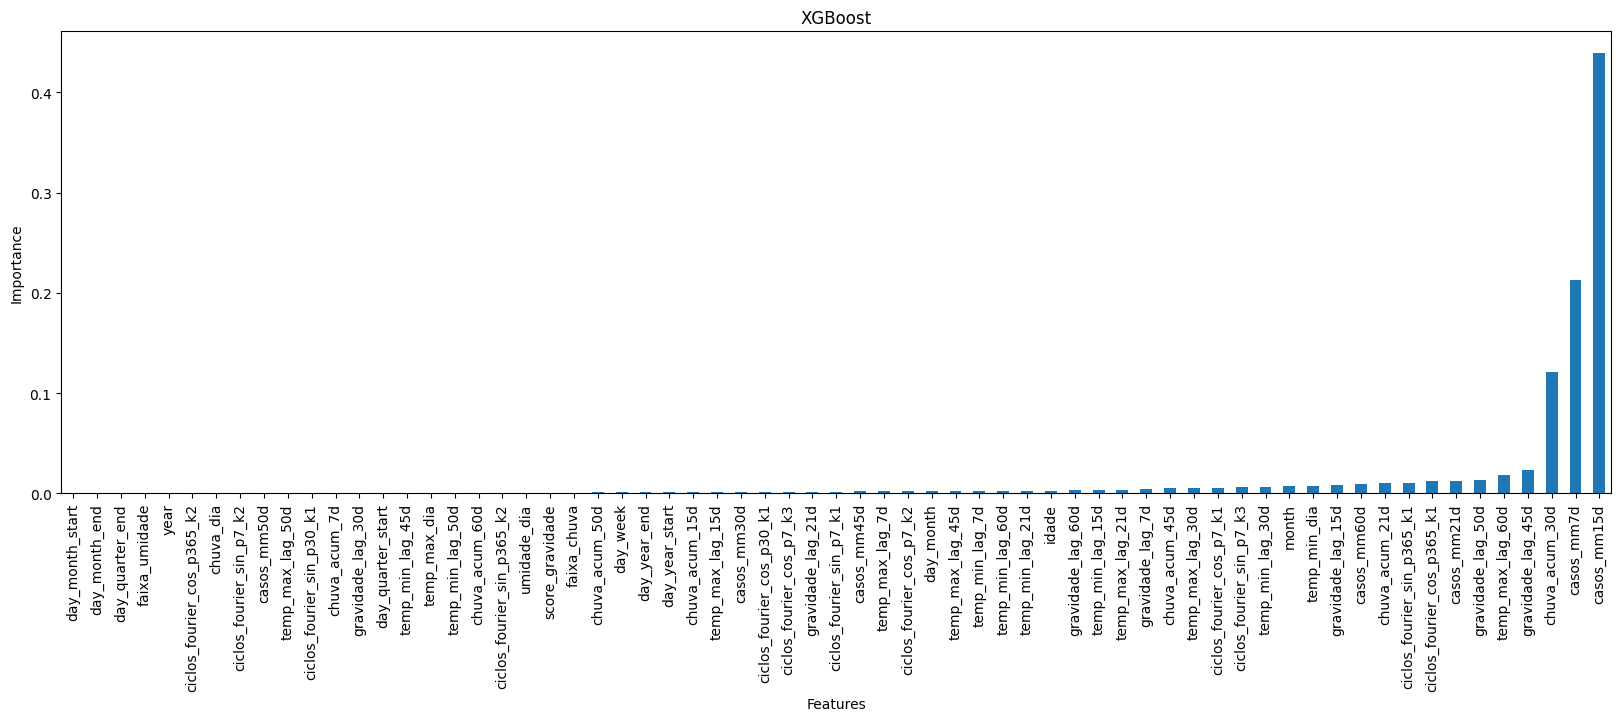

In [58]:
feat_selected_xg_boost.feature_importances_.plot.bar(figsize=(20,6))
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title(label=f'{model_name}')
plt.show()

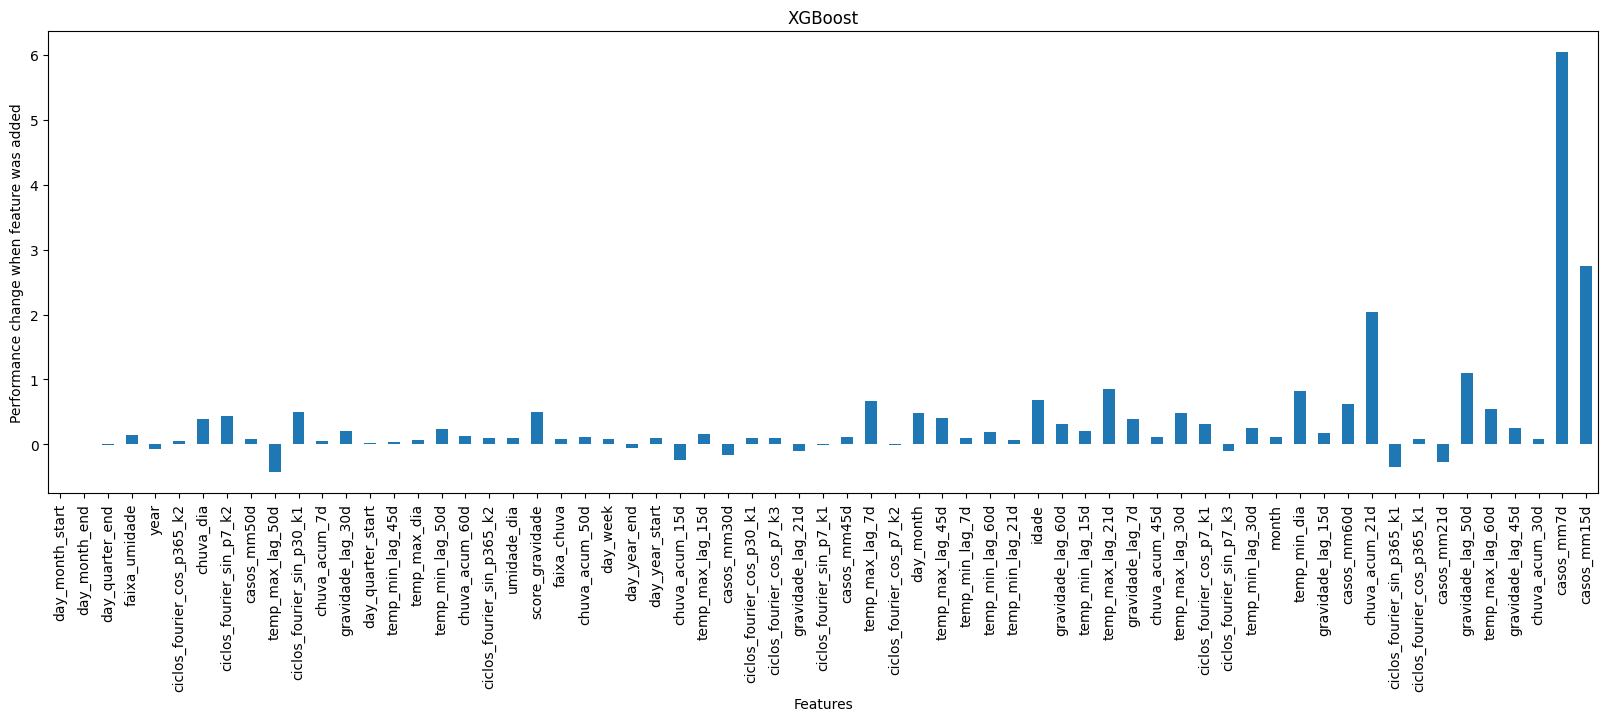

In [59]:
pd.Series(feat_selected_xg_boost.performance_drifts_).plot.bar(figsize=(20,6))
plt.xlabel('Features')
plt.ylabel('Performance change when feature was added')
plt.title(label=f'{model_name}')
plt.show()

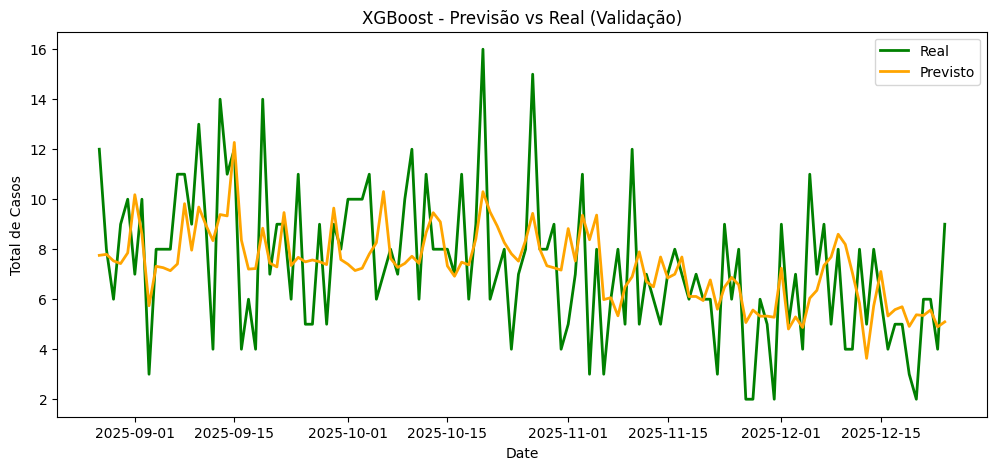

In [60]:
plt.figure(figsize=(12,5))
plt.plot(y_val.index, y_val, label='Real',  color='green', lw=2)
plt.plot(y_val.index, y_pred_xg_boost, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} - Previsão vs Real (Validação)")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [61]:
metrics_val = get_erros_metric(y_val, y_pred_xg_boost, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_val', metrics_val)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.926978,5.816791,2.411802,0.281779,1162.63944


In [62]:
X_test_selected = X_test_scaled.drop(columns=feat_selected_xg_boost.features_to_drop_)
X_test_selected.shape, X_test_selected.columns

((120, 51),
 Index(['score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia', 'temp_min_dia',
        'umidade_dia', 'month', 'day_week', 'chuva_acum_7d', 'gravidade_lag_7d',
        'gravidade_lag_15d', 'chuva_acum_21d', 'chuva_acum_30d',
        'gravidade_lag_30d', 'chuva_acum_45d', 'gravidade_lag_45d',
        'chuva_acum_50d', 'gravidade_lag_50d', 'chuva_acum_60d',
        'gravidade_lag_60d', 'casos_mm7d', 'casos_mm15d', 'casos_mm45d',
        'casos_mm50d', 'casos_mm60d', 'temp_min_lag_7d', 'temp_min_lag_15d',
        'temp_min_lag_21d', 'temp_min_lag_30d', 'temp_min_lag_45d',
        'temp_min_lag_50d', 'temp_min_lag_60d', 'temp_max_lag_7d',
        'temp_max_lag_15d', 'temp_max_lag_21d', 'temp_max_lag_30d',
        'temp_max_lag_45d', 'temp_max_lag_60d', 'faixa_chuva', 'faixa_umidade',
        'day_month', 'day_quarter_start', 'day_year_start',
        'ciclos_fourier_cos_p7_k1', 'ciclos_fourier_sin_p7_k2',
        'ciclos_fourier_cos_p7_k3', 'ciclos_fourier_cos_p30_k1',
      

In [63]:
y_pred_final = model_xg_boost.predict(X_test_selected)

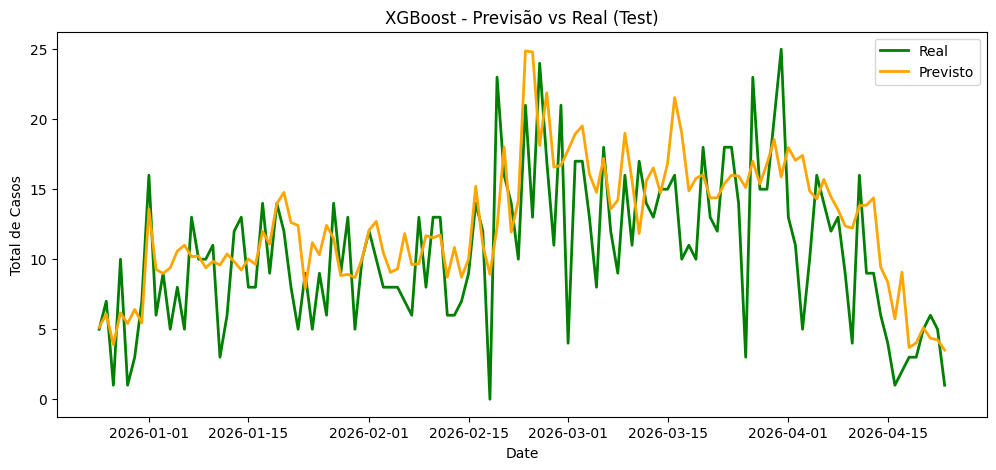

In [64]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
plt.plot(y_test.index, y_pred_final, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} - Previsão vs Real (Test)")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [65]:
metrics_test = get_erros_metric(y_test, y_pred_final, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_test', metrics_test)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.926978,5.816791,2.411802,0.281779,1162.63944
1,XGBoost_test,2025-12-25,2026-04-23,3.468408,19.723609,4.441127,0.299277,1162.63944


In [66]:
# Em séries temporais, como o seu projeto de dengue/saúde, após você validar tudo
# e chegar à conclusão de que o modelo é bom usando o `X_val`, existe um passo extra muito comum:

# **Retreinar o modelo com Treino + Validação:**
# Antes de fazer a predição final no Teste, muitos cientistas de dados juntam o Treino e
# a Validação em um único bloco e treinam o modelo uma última vez com esses dados combinados.
# Porque assim o modelo terá visto os dados mais recentes (da validação)
# antes de tentar prever o teste, o que é valioso para capturar as tendências mais próximas de 2026.

X_train_selected = X_train_scaled.drop(columns=feat_selected_xg_boost.features_to_drop_)
X_val_selected = X_val_scaled.drop(columns=feat_selected_xg_boost.features_to_drop_)


# Juntar treino e val para o último treino antes do teste real
X_final_train = pd.concat([X_train_selected, X_val_selected])
y_final_train = pd.concat([y_train, y_val])

# X_test_selected = X_test_scaled.drop(columns=feat_selected_xg_boost.features_to_drop_)

model_xg_boost.fit(X_final_train, y_final_train)
y_pred_final_agg = model_xg_boost.predict(X_test_selected) # Comparar com y_test

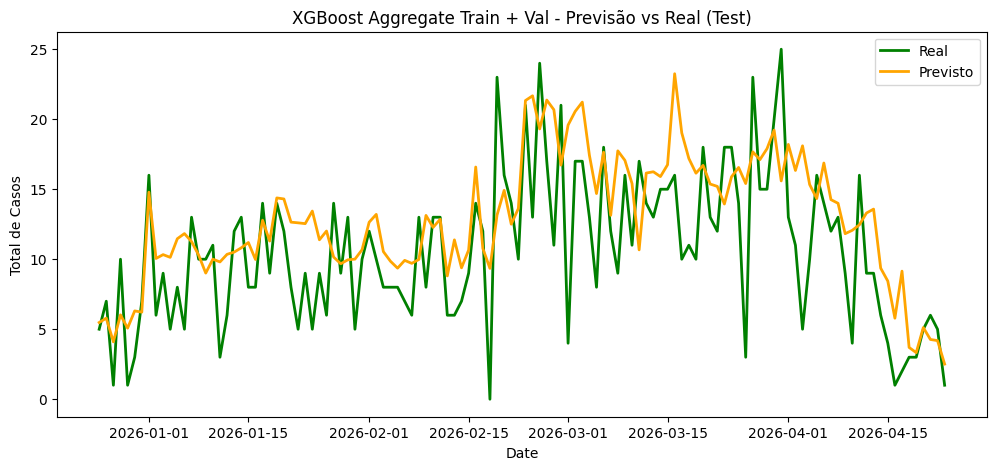

In [67]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
plt.plot(y_test.index, y_pred_final_agg, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} Aggregate Train + Val - Previsão vs Real (Test)")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [68]:
metrics_test_agg = get_erros_metric(y_test, y_pred_final_agg, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_test_agg', metrics_test_agg)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.926978,5.816791,2.411802,0.281779,1162.63944
1,XGBoost_test,2025-12-25,2026-04-23,3.468408,19.723609,4.441127,0.299277,1162.63944
2,XGBoost_test_agg,2025-12-25,2026-04-23,3.670646,21.882373,4.677860,0.222582,1162.63944


In [69]:
# Como o 3.43 é melhor que o 3.58, prova que incluir o período de validação no treino final vale a pena

In [70]:
# Parâmetros vs. Pesos (Aprendizado)
# Existe uma diferença crucial entre Hiperparâmetros e Pesos aprendidos:

# Hiperparâmetros (best_params): São as configurações da "máquina"
# (ex: profundidade da árvore = 5, taxa de aprendizado = 0.1).
# Eles dizem como o modelo deve aprender, mas não o que ele aprendeu.

# Pesos/Árvores aprendidas: É o conhecimento real.
# Quando você rodou o forecasting, o modelo model_xg_boost aprendeu os padrões de 2020 até agosto de 2025.

# Se você apenas usar o model_xg_boost.predict(X_test),
# ele usará o conhecimento que para em agosto de 2025 para tentar prever 2026.
# Ao rodar o .fit() novamente com os dados combinados, você não está mudando as
# "configurações" (hiperparâmetros), mas está permitindo que
# o modelo "leia os capítulos mais recentes" da história (o set de Validação).

# A "Janela de Memória" em Séries Temporais
# Sem o retreino: O modelo tenta prever o futuro com uma "lacuna" de informação
# (os 60-87 dias da validação que ele nunca viu).

# Com o retreino: O modelo encosta no "presente" antes de saltar para o futuro (Teste).
# Isso geralmente reduz drasticamente o erro (MAE) porque ele captura a inclinação da curva de casos mais recente.

# LightGBM

In [71]:
start_time = time.time()
model_name = 'LightGBM'
y_pred_gbm, best_params_gbm, feat_selected_gbm, model_gbm = forecasting(X_train_scaled, y_train, X_val_scaled, model_name, 50)
end_time = time.time()

[I 2026-05-11 23:24:21,870] A new study created in memory with name: no-name-34b7a7fb-c352-4b20-acc5-30356c03bf1e
[I 2026-05-11 23:24:49,287] Trial 0 finished with value: 42.623429776027486 and parameters: {'n_estimators': 117, 'max_depth': 5, 'learning_rate': 0.03129473078698329, 'num_leaves': 53, 'subsample': 0.9903979639266245, 'colsample_bytree': 0.893180551614721}. Best is trial 0 with value: 42.623429776027486.
[I 2026-05-11 23:24:58,915] Trial 1 finished with value: 41.47811739846247 and parameters: {'n_estimators': 148, 'max_depth': 3, 'learning_rate': 0.01966042212307697, 'num_leaves': 58, 'subsample': 0.6560639571149198, 'colsample_bytree': 0.740168231263725}. Best is trial 1 with value: 41.47811739846247.
[I 2026-05-11 23:25:25,673] Trial 2 finished with value: 43.75134344207259 and parameters: {'n_estimators': 219, 'max_depth': 6, 'learning_rate': 0.056467764020929026, 'num_leaves': 57, 'subsample': 0.9811065033652491, 'colsample_bytree': 0.8366152134584268}. Best is trial 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001052 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11828
[LightGBM] [Info] Number of data points in the train set: 1604, number of used features: 61
[LightGBM] [Info] Start training from score 55.598504
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000988 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12065
[LightGBM] [Info] Number of data points in the train set: 1604, number of used features: 61
[LightGBM] [Info] Start training from score 54.667082
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001128 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12567
[LightGBM] [Info] Number of data points in the train set: 1604, number of used features: 61
[LightGBM] [Info] Start t

In [72]:
print(f'{model_name}: {best_params_gbm}')

LightGBM: {'n_estimators': 268, 'max_depth': 3, 'learning_rate': 0.010032466225544776, 'num_leaves': 51, 'subsample': 0.5945653306587324, 'colsample_bytree': 0.8497352099168403}


In [73]:
feat_selected_gbm.initial_model_performance_

np.float64(-64.98967986896976)

In [74]:
len(feat_selected_gbm.features_to_drop_)

21

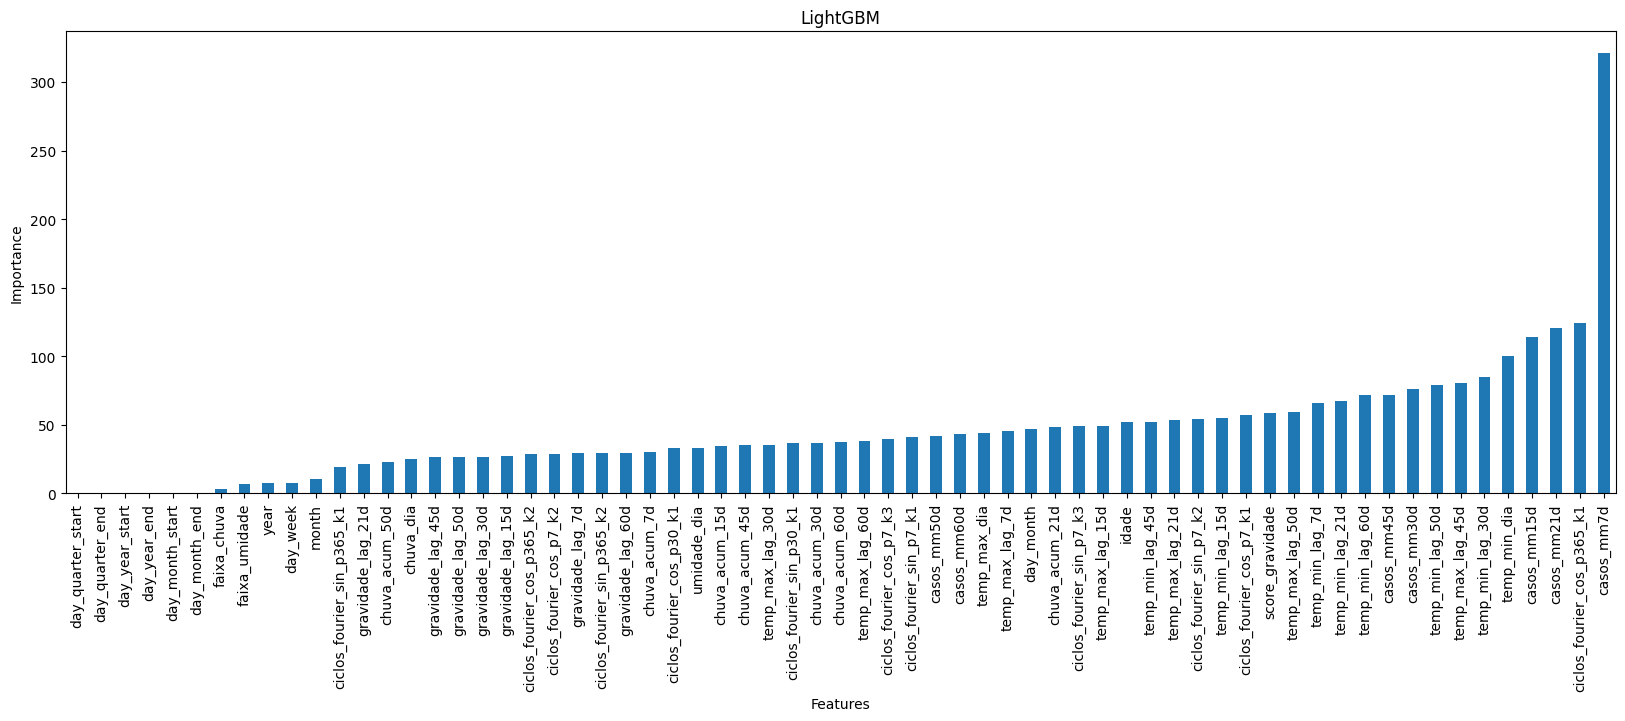

In [75]:
feat_selected_gbm.feature_importances_.plot.bar(figsize=(20,6))
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title(label=f'{model_name}')
plt.show()

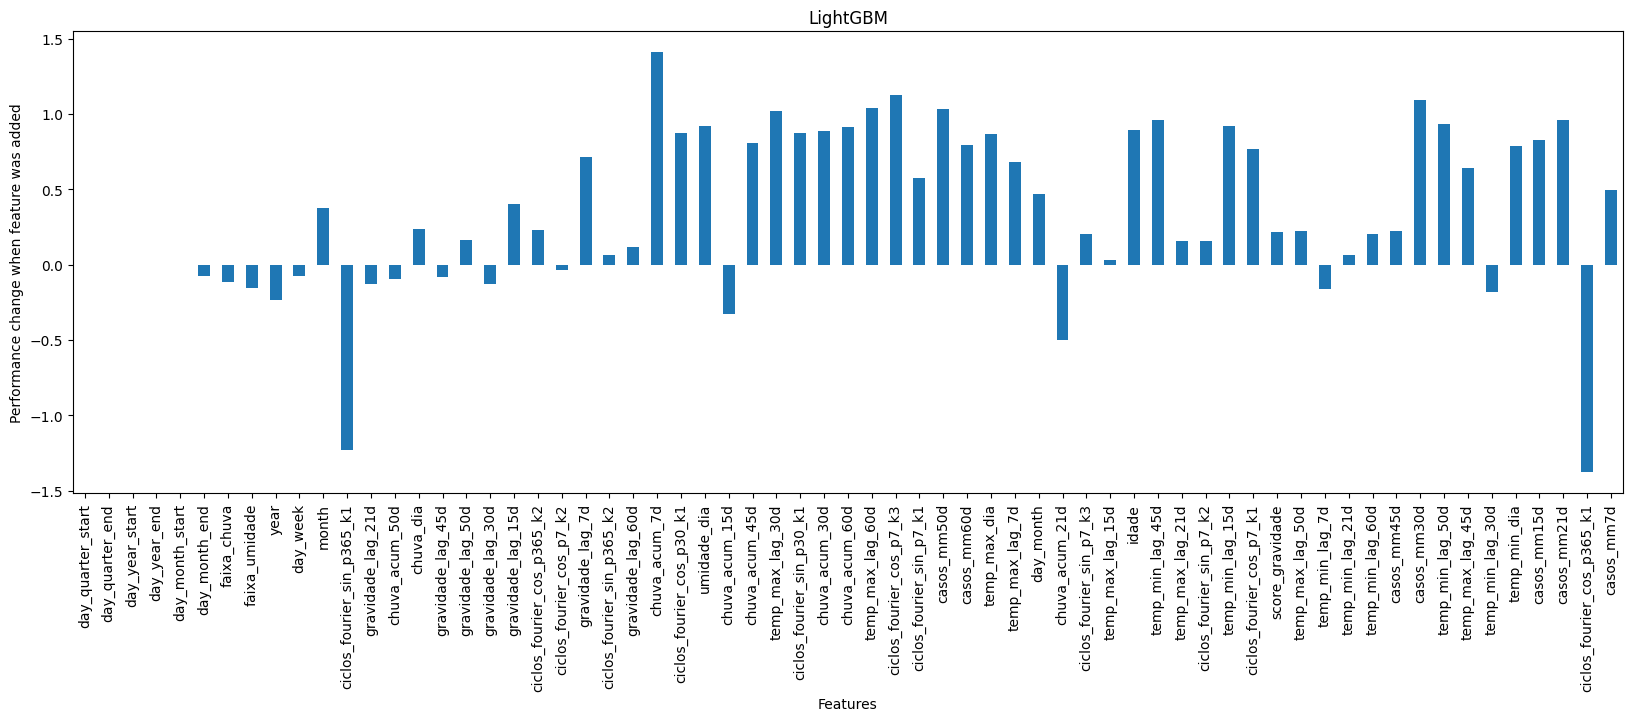

In [76]:
pd.Series(feat_selected_gbm.performance_drifts_).plot.bar(figsize=(20,6))
plt.xlabel('Features')
plt.ylabel('Performance change when feature was added')
plt.title(label=f'{model_name}')
plt.show()

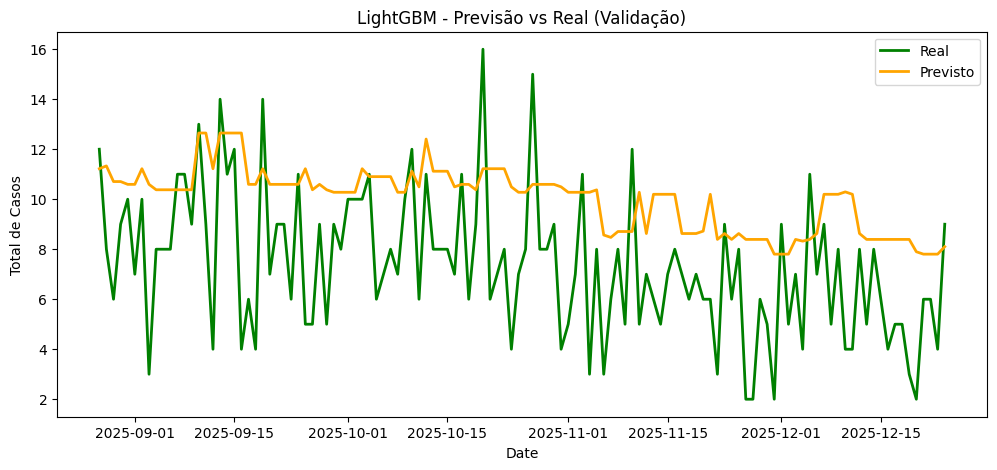

In [77]:
plt.figure(figsize=(12,5))
plt.plot(y_val.index, y_val, label='Real',  color='green', lw=2)
plt.plot(y_val.index, y_pred_gbm, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} - Previsão vs Real (Validação)")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [78]:
metrics_ = dict()
metrics_ = get_erros_metric(y_val, y_pred_gbm, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_val', metrics_)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.926978,5.816791,2.411802,0.281779,1162.639440
1,XGBoost_test,2025-12-25,2026-04-23,3.468408,19.723609,4.441127,0.299277,1162.639440
2,XGBoost_test_agg,2025-12-25,2026-04-23,3.670646,21.882373,4.677860,0.222582,1162.639440
3,LightGBM_val,2025-08-27,2025-12-24,3.082863,13.375090,3.657197,-0.651472,1330.995342


In [79]:
X_test_selected = X_test_scaled.drop(columns=feat_selected_gbm.features_to_drop_)
X_test_selected.shape, X_test_selected.columns

((120, 44),
 Index(['score_gravidade', 'idade', 'chuva_dia', 'temp_max_dia', 'temp_min_dia',
        'umidade_dia', 'month', 'chuva_acum_7d', 'gravidade_lag_7d',
        'gravidade_lag_15d', 'chuva_acum_30d', 'chuva_acum_45d',
        'gravidade_lag_50d', 'chuva_acum_60d', 'gravidade_lag_60d',
        'casos_mm7d', 'casos_mm15d', 'casos_mm21d', 'casos_mm30d',
        'casos_mm45d', 'casos_mm50d', 'casos_mm60d', 'temp_min_lag_15d',
        'temp_min_lag_21d', 'temp_min_lag_45d', 'temp_min_lag_50d',
        'temp_min_lag_60d', 'temp_max_lag_7d', 'temp_max_lag_15d',
        'temp_max_lag_21d', 'temp_max_lag_30d', 'temp_max_lag_45d',
        'temp_max_lag_50d', 'temp_max_lag_60d', 'day_month',
        'ciclos_fourier_cos_p7_k1', 'ciclos_fourier_sin_p7_k1',
        'ciclos_fourier_sin_p7_k2', 'ciclos_fourier_cos_p7_k3',
        'ciclos_fourier_sin_p7_k3', 'ciclos_fourier_cos_p30_k1',
        'ciclos_fourier_sin_p30_k1', 'ciclos_fourier_cos_p365_k2',
        'ciclos_fourier_sin_p365_k2'],
  

In [80]:
y_pred_final = model_gbm.predict(X_test_selected)

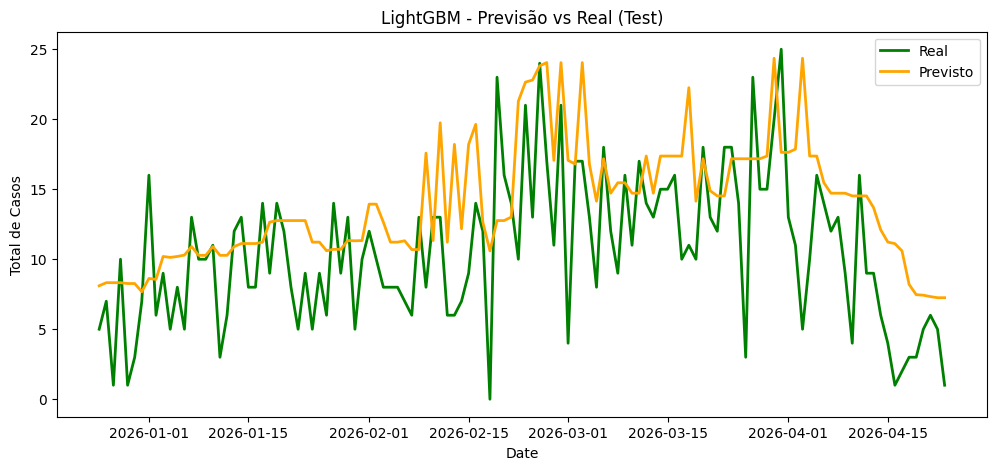

In [81]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
plt.plot(y_test.index, y_pred_final, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} - Previsão vs Real (Test)")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [82]:
metrics_ = dict()
metrics_ = get_erros_metric(y_test, y_pred_final, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_test', metrics_)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.926978,5.816791,2.411802,0.281779,1162.639440
1,XGBoost_test,2025-12-25,2026-04-23,3.468408,19.723609,4.441127,0.299277,1162.639440
2,XGBoost_test_agg,2025-12-25,2026-04-23,3.670646,21.882373,4.677860,0.222582,1162.639440
3,LightGBM_val,2025-08-27,2025-12-24,3.082863,13.375090,3.657197,-0.651472,1330.995342
4,LightGBM_test,2025-12-25,2026-04-23,4.429630,31.036522,5.571043,-0.102639,1330.995342


In [83]:
X_train_selected = X_train_scaled.drop(columns=feat_selected_gbm.features_to_drop_)
X_val_selected = X_val_scaled.drop(columns=feat_selected_gbm.features_to_drop_)

In [84]:
# Juntar treino e val para o último treino antes do teste real
X_final_train = pd.concat([X_train_selected, X_val_selected])
y_final_train = pd.concat([y_train, y_val])

model_gbm.fit(X_final_train, y_final_train)
y_pred_final_agg = model_gbm.predict(X_test_selected) # Comparar com y_test

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000826 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9965
[LightGBM] [Info] Number of data points in the train set: 2125, number of used features: 44
[LightGBM] [Info] Start training from score 42.820706
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

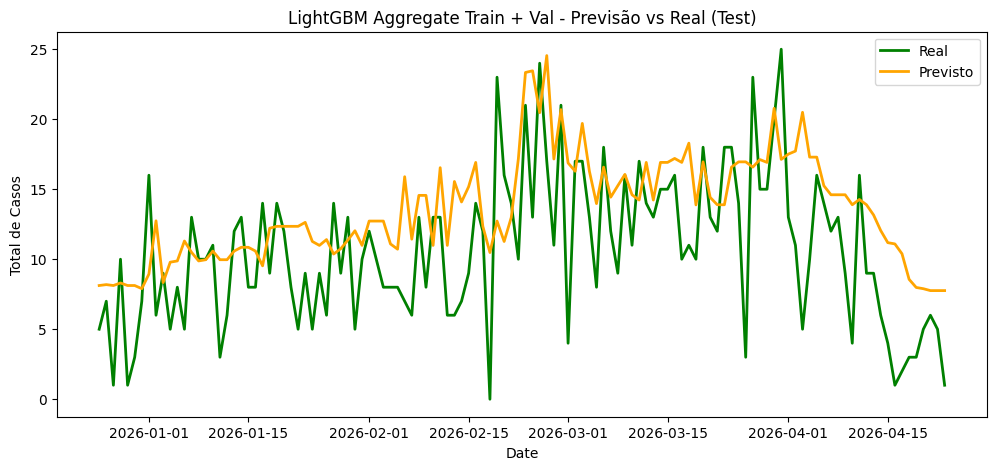

In [85]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
plt.plot(y_test.index, y_pred_final_agg, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} Aggregate Train + Val - Previsão vs Real (Test)")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [86]:
metrics_ = dict()
metrics_ = get_erros_metric(y_test, y_pred_final_agg, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_test_agg', metrics_)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.926978,5.816791,2.411802,0.281779,1162.639440
1,XGBoost_test,2025-12-25,2026-04-23,3.468408,19.723609,4.441127,0.299277,1162.639440
2,XGBoost_test_agg,2025-12-25,2026-04-23,3.670646,21.882373,4.677860,0.222582,1162.639440
3,LightGBM_val,2025-08-27,2025-12-24,3.082863,13.375090,3.657197,-0.651472,1330.995342
4,LightGBM_test,2025-12-25,2026-04-23,4.429630,31.036522,5.571043,-0.102639,1330.995342
5,LightGBM_test_agg,2025-12-25,2026-04-23,4.218553,27.420333,5.236443,0.025834,1330.995342


# LSTM

In [113]:
model_name = 'LSTM'

In [87]:
import tensorflow.compat.v2 as tf

In [149]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [148]:
from tensorflow.keras.layers import LSTM, Bidirectional, BatchNormalization
from tensorflow.keras.optimizers import Adam

In [90]:
tf.keras.backend.clear_session()

In [91]:
# Nunca use o mesmo objeto scaler que você usou para o X
scaler_y = StandardScaler()

In [92]:
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val_scaled  = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))

In [93]:
X_train_scaled_np = X_train_scaled.values  # converte para NumPy array
X_val_scaled_np  = X_val_scaled.values
X_test_scaled_np  = X_test_scaled.values

In [94]:
# --- Remodelar para LSTM ---
X_train_lstm = X_train_scaled_np.reshape((X_train_scaled_np.shape[0], 1, X_train_scaled_np.shape[1]))
X_val_lstm  = X_val_scaled_np.reshape((X_val_scaled_np.shape[0], 1, X_val_scaled_np.shape[1]))
X_test_lstm  = X_test_scaled_np.reshape((X_test_scaled_np.shape[0], 1, X_test_scaled_np.shape[1]))

In [127]:
# def lstm_model(X_train_lstm):
#   model_lstm = Sequential([
#       LSTM(64, activation='tanh', return_sequences=True, input_shape=(1, X_train_lstm.shape[2])),
#       Dropout(0.2),
#       LSTM(32, activation='tanh'),
#       Dropout(0.2),
#       Dense(1)
#   ])
#   optimizer = Adam(learning_rate=0.001)
#   model_lstm.compile(optimizer=optimizer, loss='mae')
#   return model_lstm

In [177]:
def lstm_model(X_train_lstm):

  # model = Sequential([
  #     # Bidirecional para capturar mais contexto
  #     Bidirectional(LSTM(64, activation='tanh', return_sequences=True),
  #                   input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
  #     BatchNormalization(),
  #     Dropout(0.3), # Aumentado levemente se houver overfitting
  #     LSTM(32, activation='tanh'),
  #     BatchNormalization(),
  #     Dropout(0.3),
  #     Dense(1)
  # ])

  # Otimizador Adam costuma aceitar bem o valor padrão 0.001 inicial
  # model.compile(optimizer=Adam(learning_rate=0.001), loss='mae')
  from tensorflow.keras.losses import Huber
  model = Sequential([
      # Bidirecional para capturar mais contexto
      Bidirectional(LSTM(32, activation='tanh', return_sequences=True),
                    input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
      BatchNormalization(),
      Dropout(0.5), # Aumentado levemente se houver overfitting
      LSTM(16, activation='tanh'),
      BatchNormalization(),
      Dropout(0.5),
      Dense(1)
  ])

  # Em séries temporais com muita volatilidade,
  # o Huber Loss costuma ser melhor porque ele é um meio-termo entre MSE e MAE
  model.compile(optimizer=Adam(learning_rate=0.001), loss=Huber()) # loss='huber_loss')
  return model

In [178]:
model_lstm = lstm_model(X_train_lstm)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [179]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [180]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,      # Reduz a taxa de aprendizado pela metade
    patience=5,      # Se por 5 épocas o erro não cair
    min_lr=1e-6,     # Limite mínimo
    verbose=1
)

In [181]:
start_time = time.time()
history = model_lstm.fit(
    X_train_lstm, y_train_scaled,
    # validation_split=0.2, já fiz o split do train e val
    validation_data=(X_val_lstm, y_val_scaled),
    epochs=500,
    batch_size=32,
    verbose=1,
    callbacks=[early_stop, reduce_lr]
)
end_time = time.time()

Epoch 1/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.9566 - val_loss: 0.0293 - learning_rate: 0.0010
Epoch 2/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.6693 - val_loss: 0.0211 - learning_rate: 0.0010
Epoch 3/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5207 - val_loss: 0.0174 - learning_rate: 0.0010
Epoch 4/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.4028 - val_loss: 0.0124 - learning_rate: 0.0010
Epoch 5/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.3103 - val_loss: 0.0111 - learning_rate: 0.0010
Epoch 6/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.2519 - val_loss: 0.0102 - learning_rate: 0.0010
Epoch 7/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2176 - val_loss: 0.0111 - learning_rate: 0.0010
Epoch 8/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1772 - val_loss: 0.0097 - learning_rate: 0.0010
Epoch 9/500
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1817 - val_loss: 0.0087 - learning_rate: 0.0010
Epoch 10/5

In [182]:
y_pred_val_scaled = model_lstm.predict(X_val_lstm)
y_pred_val_lstm = scaler_y.inverse_transform(y_pred_val_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step


In [183]:
y_pred_val_lstm_ = pd.DataFrame(y_pred_val_lstm, columns=[column_target], index=y_val.index)

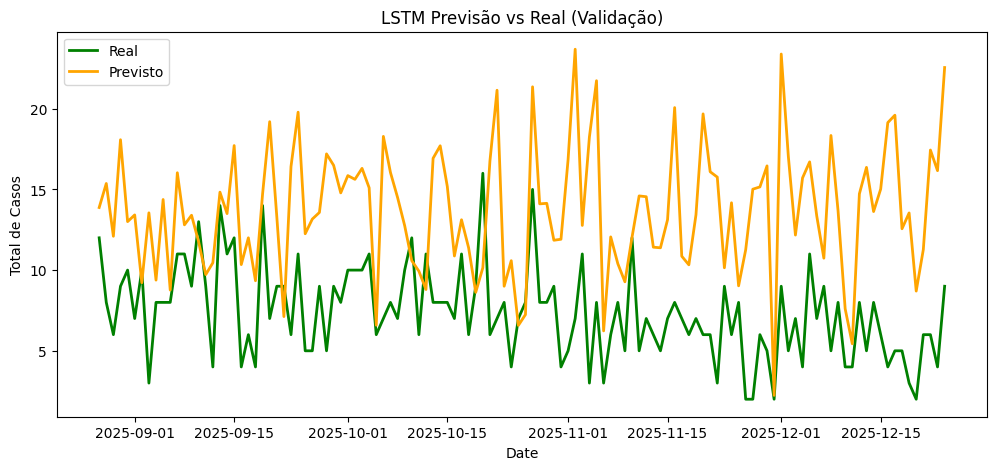

In [184]:
plt.figure(figsize=(12,5))
plt.plot(y_val.index, y_val, label='Real',  color='green', lw=2)
plt.plot(y_val.index, y_pred_val_lstm_, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} Previsão vs Real (Validação)")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [185]:
metrics_ = dict()
metrics_ = get_erros_metric(y_val, y_pred_val_lstm_, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_val', metrics_)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.926978,5.816791,2.411802,0.281779,1162.639440
1,XGBoost_test,2025-12-25,2026-04-23,3.468408,19.723609,4.441127,0.299277,1162.639440
2,XGBoost_test_agg,2025-12-25,2026-04-23,3.670646,21.882373,4.677860,0.222582,1162.639440
3,LightGBM_val,2025-08-27,2025-12-24,6.262058,62.408954,7.899934,-6.705866,21.274672
4,LightGBM_test,2025-12-25,2026-04-23,4.429630,31.036522,5.571043,-0.102639,1330.995342
5,LightGBM_test_agg,2025-12-25,2026-04-23,4.218553,27.420333,5.236443,0.025834,1330.995342
6,LSTM_val,2025-08-27,2025-12-24,6.573573,60.468293,7.776136,-6.466246,59.027472
7,LSTM_test,2025-12-25,2026-04-23,20.258165,479.668992,21.901347,-16.041264,23.642260
8,LSTM_test_agg,2025-12-25,2026-04-23,21.005952,573.901306,23.956237,-19.389069,15.751207


In [186]:
y_pred_test_scaled = model_lstm.predict(X_test_lstm)
y_pred_test_lstm = scaler_y.inverse_transform(y_pred_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


In [187]:
y_pred_test_lstm_ = pd.DataFrame(y_pred_test_lstm, columns=[column_target], index=y_test.index)

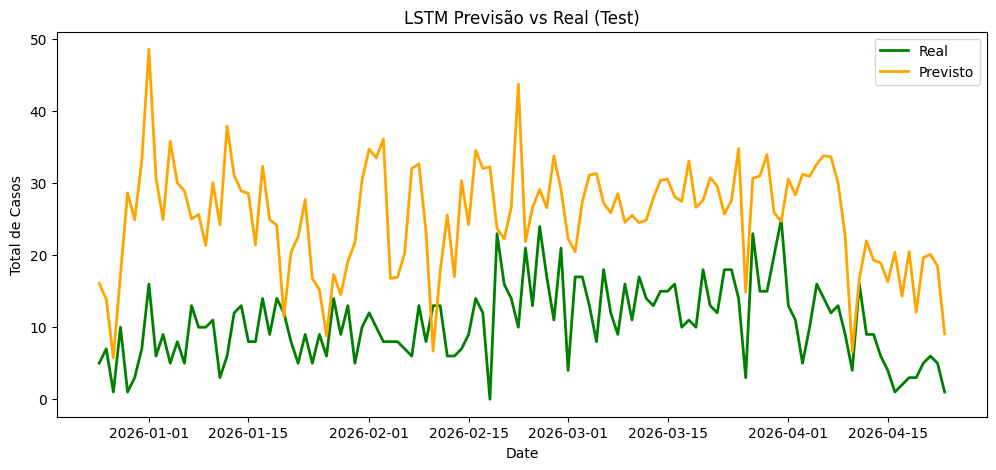

In [188]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
plt.plot(y_test.index, y_pred_test_lstm_, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} Previsão vs Real (Test)")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [189]:
metrics_ = dict()
metrics_ = get_erros_metric(y_test, y_pred_test_lstm_, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_test', metrics_)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.926978,5.816791,2.411802,0.281779,1162.639440
1,XGBoost_test,2025-12-25,2026-04-23,3.468408,19.723609,4.441127,0.299277,1162.639440
2,XGBoost_test_agg,2025-12-25,2026-04-23,3.670646,21.882373,4.677860,0.222582,1162.639440
3,LightGBM_val,2025-08-27,2025-12-24,6.262058,62.408954,7.899934,-6.705866,21.274672
4,LightGBM_test,2025-12-25,2026-04-23,4.429630,31.036522,5.571043,-0.102639,1330.995342
5,LightGBM_test_agg,2025-12-25,2026-04-23,4.218553,27.420333,5.236443,0.025834,1330.995342
6,LSTM_val,2025-08-27,2025-12-24,6.573573,60.468293,7.776136,-6.466246,59.027472
7,LSTM_test,2025-12-25,2026-04-23,14.872845,276.662751,16.633182,-8.829035,59.027472
8,LSTM_test_agg,2025-12-25,2026-04-23,21.005952,573.901306,23.956237,-19.389069,15.751207


In [190]:
# Train + Val
# 1. Unir os dados de Treino e Validação (X e y já escalonados)
X_final_train = np.concatenate((X_train_lstm, X_val_lstm), axis=0)
y_final_train = np.concatenate((y_train_scaled, y_val_scaled), axis=0)

In [191]:
best_epoch = np.argmin(history.history['val_loss']) + 1
print(f"A melhor performance foi na época: {best_epoch}")

A melhor performance foi na época: 59


In [192]:
# Re-treinar o modelo com o conjunto completo
model_lstm = lstm_model(X_train_lstm)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [193]:
# Use o número de épocas que o Early Stopping encontrou anteriormente
start_time = time.time()
history = model_lstm.fit(
    X_final_train, y_final_train,
    epochs=best_epoch, # Ou o melhor valor encontrado pelo early_stop
    batch_size=32,
    verbose=1
    # Sem validation_data aqui, pois você uniu tudo para ganhar poder estatístico
)
end_time = time.time()

Epoch 1/59
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.1763
Epoch 2/59
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.9205
Epoch 3/59
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6785
Epoch 4/59
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.5360
Epoch 5/59
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.4104
Epoch 6/59
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3382
Epoch 7/59
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.2532
Epoch 8/59
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.2271
Epoch 9/59
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1952
Epoch 10/59
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1822
Epoch 11/59
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1612
Epoch 12/59
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1470
Epoch 13/59
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1425
Epoch 14/59
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1387
Epoch 15/59
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1345
Epoch 16/59
6

In [194]:
# 3. Prever o Teste (O "mundo real" que o modelo nunca viu)
y_pred_test_scaled_final = model_lstm.predict(X_test_lstm)
y_pred_test_final = scaler_y.inverse_transform(y_pred_test_scaled_final)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step


In [195]:
y_pred_test_final_ = pd.DataFrame(y_pred_test_final, columns=[column_target], index=y_test.index)

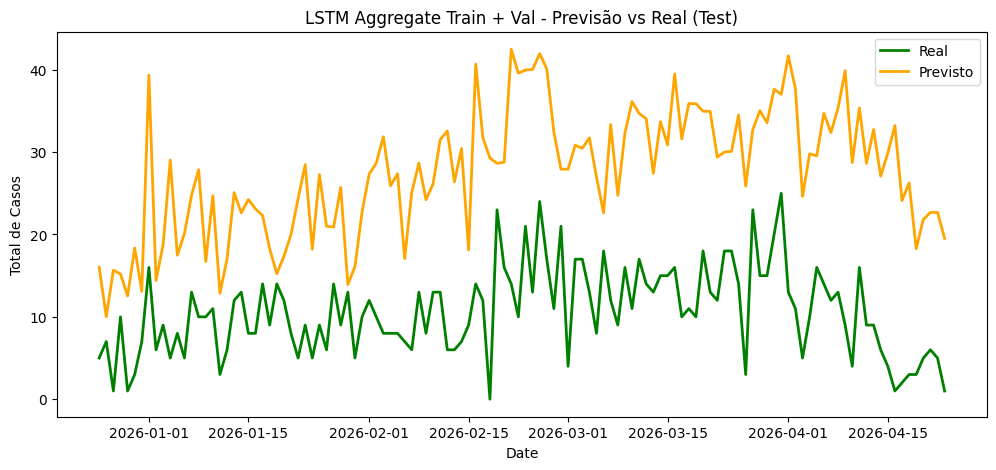

In [196]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Real',  color='green', lw=2)
plt.plot(y_test.index, y_pred_test_final_, label='Previsto', color='orange', lw=2)
plt.title(f"{model_name} Aggregate Train + Val - Previsão vs Real (Test)")
plt.xlabel("Date")
plt.ylabel("Total de Casos")
plt.legend()
plt.show()

In [197]:
metrics_ = dict()
metrics_ = get_erros_metric(y_test, y_pred_test_final_, (end_time - start_time))
df_result = add_resultado(df_result, f'{model_name}_test_agg', metrics_)
df_result

,Type,Start,End,MAE,MSE,RMSE,R2,Seconds
0,XGBoost_val,2025-08-27,2025-12-24,1.926978,5.816791,2.411802,0.281779,1162.639440
1,XGBoost_test,2025-12-25,2026-04-23,3.468408,19.723609,4.441127,0.299277,1162.639440
2,XGBoost_test_agg,2025-12-25,2026-04-23,3.670646,21.882373,4.677860,0.222582,1162.639440
3,LightGBM_val,2025-08-27,2025-12-24,6.262058,62.408954,7.899934,-6.705866,21.274672
4,LightGBM_test,2025-12-25,2026-04-23,4.429630,31.036522,5.571043,-0.102639,1330.995342
5,LightGBM_test_agg,2025-12-25,2026-04-23,4.218553,27.420333,5.236443,0.025834,1330.995342
6,LSTM_val,2025-08-27,2025-12-24,6.573573,60.468293,7.776136,-6.466246,59.027472
7,LSTM_test,2025-12-25,2026-04-23,14.872845,276.662751,16.633182,-8.829035,59.027472
8,LSTM_test_agg,2025-12-25,2026-04-23,17.025516,332.903605,18.245646,-10.827111,50.381749


# StackingRegressor

In [ ]:
# def lstm_model(X_train_lstm):
#   model_lstm = Sequential([
#       LSTM(64, activation='tanh', return_sequences=True, input_shape=(1, X_train_lstm.shape[2])),
#       Dropout(0.2),
#       LSTM(32, activation='tanh'),
#       Dropout(0.2),
#       Dense(1)
#   ])
#   optimizer = Adam(learning_rate=0.001)
#   model_lstm.compile(optimizer=optimizer, loss='mse')
#   return model_lstm

In [ ]:
# from sklearn.ensemble import StackingRegressor

In [ ]:
# BaseEstimator:
# implementa automaticamente os métodos get_params() e set_params().

# RegressorMixin:
# adiciona automaticamente o método .score().
# Para regressores, esse método calcula o R2 (coeficiente de determinação) por padrão.
# Quando o StackingRegressor ou um cross_val_score roda, ele precisa saber como avaliar o modelo.
# O RegressorMixin garante que, ao chamar modelo.score(),
# ele saiba que deve comparar previsões numéricas e retornar o erro correspondente.

# import numpy as np
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import LSTM, Dense
# from sklearn.base import BaseEstimator, RegressorMixin

In [ ]:
# class LSTMWrapper(BaseEstimator, RegressorMixin):
#     def __init__(self, n_units_l1=64, n_units_l2=32, epochs=500, batch_size=32, timesteps=1):
#         self.n_units_l1 = n_units_l1
#         self.n_units_l2 = n_units_l2
#         self.epochs = epochs
#         self.batch_size = batch_size
#         self.timesteps = timesteps
#         self.model = None

#     def fit(self, X, y):
#         X_reshaped = np.array(X).reshape((X.shape[0], self.timesteps, -1))

#         # Sua arquitetura aqui
#         self.model = Sequential([
#             LSTM(self.n_units_l1, activation='tanh', return_sequences=True,
#                  input_shape=(self.timesteps, X_reshaped.shape[2])),
#             Dropout(0.2),
#             LSTM(self.n_units_l2, activation='tanh'),
#             Dropout(0.2),
#             Dense(1)
#         ])
#         self.model.compile(optimizer=Adam(0.001), loss='mse') # 'mse' em vez de 'rsme' (que não existe nativo)

#         early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

#         self.model.fit(
#             X_reshaped, y,
#             epochs=self.epochs,
#             batch_size=self.batch_size,
#             verbose=0, # O Stacking vai rodar muitas vezes, melhor silenciar
#             callbacks=[early_stop]
#         )
#         return self

#     def predict(self, X):
#         X_reshaped = np.array(X).reshape((X.shape[0], self.timesteps, -1))
#         return self.model.predict(X_reshaped, verbose=0).flatten()

In [ ]:
# Ridge: Tende a distribuir os pesos entre todos os modelos base.

# Lasso: Pode zerar o peso de modelos que ele considera irrelevantes.
# Se você tiver 10 modelos base e quiser que o Stacking selecione apenas os melhores, use Lasso.

In [ ]:
# from sklearn.linear_model import LassoCV
# from sklearn.model_selection import TimeSeriesSplit

In [ ]:
# # 2. Definir os estimadores
# estimators = [
#     ('lstm', lstm_model),
#     ('xgb', XGBRegressor(**best_params)),
#     ('rf', rf_model)
# ]

# # 3. Criar o StackingRegressor com Lasso como Meta-Learner
# # Usamos TimeSeriesSplit porque você está usando LSTM (sinal de dado temporal)
# tscv = TimeSeriesSplit(n_splits=3)

# stacking_regressor = StackingRegressor(
#     estimators=estimators,
#     final_estimator=LassoCV(), # O "filtro" que seleciona os melhores pesos
#     cv=tscv,
#     n_jobs=1 # LSTM/Tensorflow nem sempre lida bem com multiprocessamento do sklearn
# )

In [ ]:
# 4. Treinamento
# stacking_regressor.fit(X_train, y_train)
# y_pred = stacking_regressor.predict(X_test)